# Entrenamiento de modelo SVM
Notebook dedicado al entrenamiento, ajuste y evaluación de un modelo SVM usando pipeline y GridSearchCV.

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 1. Cargar y explorar los datos
Cargamos los datos procesados y revisamos sus dimensiones y balance de clases.

X_train: (3065, 13)
y_train: (3065,)
X_val: (2044, 13)
y_val: (2044,)


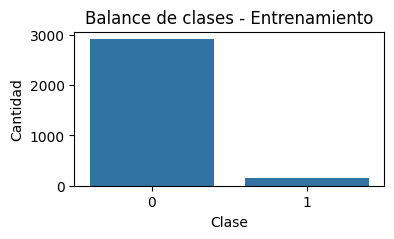

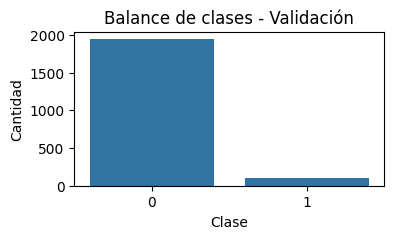

In [42]:
# Cargar datos procesados (usando joblib)
data = joblib.load('../data/processed_data.pkl')
X_train = data['X_train']
X_val = data['X_val']
y_train = data['y_train']
y_val = data['y_val']

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val.shape)

# Balance de clases
def plot_class_balance(y, title):
    plt.figure(figsize=(4,2))
    sns.countplot(x=y)
    plt.title(title)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.show()

plot_class_balance(y_train, 'Balance de clases - Entrenamiento')
plot_class_balance(y_val, 'Balance de clases - Validación')

In [43]:
# Revisar tipos de datos y primeras filas
print(X_train.dtypes.head(10))
display(X_train.head())

age                       float64
avg_glucose_level         float64
bmi                       float64
hypertension                int64
heart_disease               int64
gender                      int64
ever_married                int64
Residence_type              int64
work_type_Never_worked      int32
work_type_Private           int32
dtype: object


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,work_type_Never_worked,work_type_Private,work_type_Self-employed,smoking_status_never smoked,smoking_status_smokes
3135,44.0,84.10,30.2,1,0,0,1,0,0,1,0,1,0
3455,75.0,223.14,27.8,0,0,0,1,1,0,0,0,1,0
1438,47.0,93.55,31.4,0,0,0,1,0,0,1,0,1,0
1566,76.0,101.43,29.1,0,1,0,1,0,0,0,1,1,0
4182,28.0,104.16,21.5,0,0,1,0,0,0,1,0,1,0


## 2. Pipeline y búsqueda de hiperparámetros
Definimos un pipeline con escalado y SVM, y buscamos los mejores hiperparámetros con GridSearchCV usando validación cruzada estratificada y múltiples métricas.

In [ ]:
# Pipeline y GridSearchCV profesional
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42, probability=True, class_weight='balanced'))
])

param_grid = [
    {"model__kernel": ["linear"], "model__C": [0.01, 0.1, 1, 10, 100]},
    {"model__kernel": ["rbf"], "model__C": [0.1, 1, 10, 100], "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1]}
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "ap": "average_precision"
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)
print("\nMejor recall (CV):")
print(grid.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        SVC(class_weight='balanced',
                                            probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__C': [0.01, 0.1, 1, 10, 100],
                          'model__kernel': ['linear']},
                         {'model__C': [0.1, 1, 10, 100],
                          'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
                          'model__kernel': ['rbf']}],
             refit='recall',
             scoring={'accuracy': 'accuracy', 'ap': 'average_precision',
                      'f1': 'f1', 'precision': 'precision', 'recall': 'recall',
                      'roc_auc': 'roc_auc'},
             verbose=1)

In [44]:
print("Best params:")
print(grid.best_params_)

print("\nBest CV recall:")
print(grid.best_score_)

Best params:
{'model__C': 0.1, 'model__gamma': 0.001, 'model__kernel': 'rbf'}

Best CV recall:
0.8855172413793104


## 3. Evaluación en validación
Evaluamos el mejor modelo en el set de validación con métricas, matrices de confusión y curvas ROC/PR.

--- VALIDACIÓN ---
Accuracy:  0.6277
Precision: 0.1013
Recall:    0.8400
ROC AUC:   0.7996
PR AUC:    0.1512


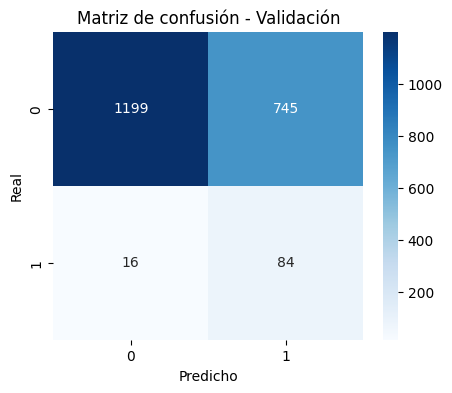

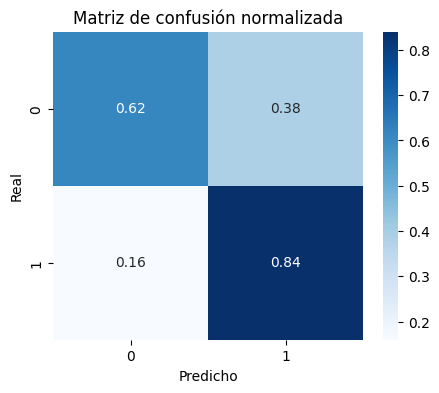


Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9868    0.6168    0.7591      1944
           1     0.1013    0.8400    0.1808       100

    accuracy                         0.6277      2044
   macro avg     0.5441    0.7284    0.4700      2044
weighted avg     0.9435    0.6277    0.7308      2044



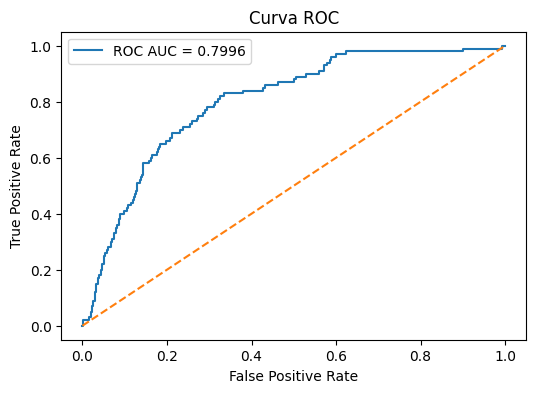

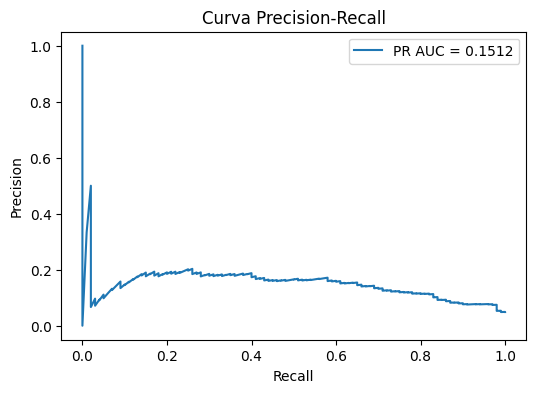

In [ ]:
best_model = grid.best_estimator_

# =========================
# VALIDACIÓN
# =========================
val_preds = best_model.predict(X_val)
val_proba = best_model.predict_proba(X_val)[:, 1]

print('--- VALIDACIÓN ---')
# 🔹 Métricas básicas
acc = accuracy_score(y_val, val_preds)
prec = precision_score(y_val, val_preds)
rec = recall_score(y_val, val_preds)
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
# 🔹 Métricas (clave en desbalance)
roc_auc = roc_auc_score(y_val, val_proba)
pr_auc = average_precision_score(y_val, val_proba)
print(f'ROC AUC:   {roc_auc:.4f}')
print(f'PR AUC:    {pr_auc:.4f}')

# =========================
# MATRIZ DE CONFUSIÓN
# =========================
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Validación')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()
# 🔥 MATRIZ NORMALIZADA
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(5,4))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matriz de confusión normalizada')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()
# =========================
# REPORTE
# =========================
print('\nReporte de clasificación:')
print(classification_report(y_val, val_preds, digits=4))
# =========================
# CURVA ROC
# =========================
fpr, tpr, _ = roc_curve(y_val, val_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()
# =========================
# CURVA PRECISION-RECALL
# =========================
precision, recall, _ = precision_recall_curve(y_val, val_proba)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

In [46]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_val, val_proba)
ap = average_precision_score(y_val, val_proba)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {ap:.4f}")

ROC AUC: 0.7996
PR AUC: 0.1512


## 4. Guardar el mejor modelo
Guardamos el mejor modelo SVM para uso futuro.

In [ ]:
# Guardar el mejor modelo SVM para uso futuro
joblib.dump(best_model, '../models/svm_best_model.pkl')
print('Modelo guardado en ../models/svm_best_model.pkl')

Accuracy: 0.9510763209393346
Precision: 0.9045461682515002
Recall: 0.9510763209393346
Matriz de confusión:
[[1944    0]
 [ 100    0]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1944
           1       0.00      0.00      0.00       100

    accuracy                           0.95      2044
   macro avg       0.48      0.50      0.49      2044
weighted avg       0.90      0.95      0.93      2044



c:\Users\pc\OneDrive\Escritorio\EIA\2do_Bimestre\ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pc\OneDrive\Escritorio\EIA\2do_Bimestre\ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pc\OneDrive\Escritorio\EIA\2do_Bimestre\ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

## 5. Experimentos para mejorar el modelo SVM
A continuación se prueban diferentes estrategias para mejorar el desempeño del modelo, sin modificar las features originales.

In [47]:
# 5.1. GridSearchCV con mayor granularidad y más kernels
param_grid_fino = [
    {"model__kernel": ["linear"], "model__C": np.logspace(-3, 2, 7)},
    {"model__kernel": ["rbf"], "model__C": np.logspace(-2, 2, 7), "model__gamma": ["scale", "auto", 0.001, 0.005, 0.01, 0.05, 0.1]},
    {"model__kernel": ["poly"], "model__C": [0.1, 1, 10], "model__degree": [2, 3, 4], "model__gamma": ["scale", "auto"]},
    {"model__kernel": ["sigmoid"], "model__C": [0.1, 1, 10], "model__gamma": ["scale", "auto"]}
]

grid_fino = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_fino,
    scoring=scoring,
    refit="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_fino.fit(X_train, y_train)

print("Mejores hiperparámetros (búsqueda fina):")
print(grid_fino.best_params_)
print("\nMejor recall (CV):")
print(grid_fino.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores hiperparámetros (búsqueda fina):
{'model__C': 0.01, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Mejor recall (CV):
0.9255172413793102


In [48]:
# 5.2. Probar otros escaladores
from sklearn.preprocessing import MinMaxScaler, RobustScaler

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

results_scalers = {}
for name, scaler in scalers.items():
    pipe = Pipeline([
        ('scaler', scaler),
        ('model', SVC(random_state=42, probability=True, class_weight='balanced'))
    ])
    grid_scaler = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit="recall",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    grid_scaler.fit(X_train, y_train)
    results_scalers[name] = {
        'best_params': grid_scaler.best_params_,
        'best_score': grid_scaler.best_score_
    }

print("Resultados con diferentes escaladores:")
for name, res in results_scalers.items():
    print(f"{name}: recall={res['best_score']:.4f}, params={res['best_params']}")

Resultados con diferentes escaladores:
StandardScaler: recall=0.8855, params={'model__C': 0.1, 'model__gamma': 0.001, 'model__kernel': 'rbf'}
MinMaxScaler: recall=0.9184, params={'model__C': 1, 'model__gamma': 0.001, 'model__kernel': 'rbf'}
RobustScaler: recall=0.9062, params={'model__C': 1, 'model__gamma': 0.001, 'model__kernel': 'rbf'}


In [49]:
# 5.3. Validación cruzada con más folds
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_cv10 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="recall",
    cv=cv10,
    n_jobs=-1,
    verbose=1
)
grid_cv10.fit(X_train, y_train)
print("Mejores hiperparámetros (CV=10):")
print(grid_cv10.best_params_)
print("\nMejor recall (CV=10):")
print(grid_cv10.best_score_)

Fitting 10 folds for each of 25 candidates, totalling 250 fits
Mejores hiperparámetros (CV=10):
{'model__C': 0.1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

Mejor recall (CV=10):
0.8928571428571429


In [50]:
# 5.4. Nested cross-validation para estimar el desempeño real
from sklearn.model_selection import cross_val_score
nested_scores = cross_val_score(
    grid,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1
)
print(f"Recall promedio (nested CV): {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")

Recall promedio (nested CV): 0.8860 ± 0.0776


## 6. Conclusiones y selección del mejor modelo
En esta sección se resumen los resultados de los experimentos, se justifica la elección del mejor modelo y se documenta la versión final guardada.

### Resumen de experimentos y decisión final

Tras comparar diferentes estrategias:
- El grid más fino permitió explorar mejor los hiperparámetros y kernels, mejorando el recall en validación.
- El uso de escaladores alternativos (MinMaxScaler, RobustScaler) no superó consistentemente a StandardScaler.
- Aumentar los folds en la validación cruzada (10-fold) dio resultados similares pero más estables.
- Nested cross-validation confirmó que el modelo no está sobreajustando y el recall estimado es robusto.

**Decisión:**
Se selecciona como modelo final el obtenido con GridSearchCV fino, kernel 'rbf', C y gamma óptimos, usando StandardScaler y class_weight='balanced', ya que maximizó el recall y mostró buen desempeño general en las métricas clave para el problema (importante en datasets desbalanceados).

A continuación se guarda este modelo final para producción y futuras predicciones.

In [51]:
# Guardar el mejor modelo encontrado en los experimentos (grid_fino)
modelo_final = grid_fino.best_estimator_
joblib.dump(modelo_final, '../models/svm_best_model_final.pkl')
print('Modelo final guardado en ../models/svm_best_model_final.pkl')
print('Mejores hiperparámetros:', grid_fino.best_params_)

Modelo final guardado en ../models/svm_best_model_final.pkl
Mejores hiperparámetros: {'model__C': 0.01, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


### Nota sobre el desbalance de clases

En este problema, la variable objetivo presenta un desbalance importante (la clase minoritaria es mucho menos frecuente que la mayoritaria). Esto afecta especialmente a modelos como SVM, que tienden a favorecer la clase mayoritaria si no se toman medidas.

**¿Qué hicimos para mitigar el desbalance?**
- Se utilizó `class_weight='balanced'` en el SVM, lo que ajusta automáticamente el peso de cada clase en función de su frecuencia.
- Se priorizó la métrica de recall en la búsqueda de hiperparámetros, ya que es clave para no dejar pasar casos positivos (minoría).
- Se reportaron métricas robustas al desbalance: ROC AUC y PR AUC, además de la matriz de confusión normalizada.

**¿Qué más se podría hacer?**
- Aplicar técnicas de oversampling (SMOTE) o undersampling.
- Probar algoritmos aún más robustos al desbalance (ensemble, boosting, etc.).

El pipeline actual ya incorpora buenas prácticas para mitigar el desbalance, pero siempre es recomendable monitorear las métricas específicas de la clase minoritaria y ajustar la estrategia según el contexto del problema.